# 05_Expert_Rule_Validation_Hybrid_Scoring

En este notebook se incorpora una capa de reglas expertas sobre los resultados del Autoencoder ajustado en el notebook 04. El objetivo es construir un sistema híbrido que combine:

- un score aprendido por el modelo (`ae_score`)
- un score interpretable basado en reglas expertas marítimas

Dado que en este trabajo interesa especialmente no perder anomalías relevantes, el sistema híbrido se diseñará priorizando **recall**, manteniendo al mismo tiempo una precisión razonable.

La literatura sobre detección de anomalías marítimas con AIS muestra que los comportamientos anómalos suelen reflejarse en patrones cinemáticos o de transmisión, como cambios anómalos de velocidad, variaciones bruscas de rumbo, trayectorias erráticas, desviaciones del comportamiento normal o interrupciones de la señal AIS. Pallotta et al. (2013) plantean la detección de anomalías como desviaciones respecto a patrones de tráfico aprendidos a partir de AIS. Las revisiones recientes de Wolsing et al. (2022) y Ribeiro et al. (2023) también destacan que la anomalía marítima en AIS suele estar ligada a irregularidades cinemáticas, de ruta o de transmisión.

Además, IMO indica que los buques sujetos a AIS deben mantenerlo operativo en todo momento, salvo excepciones concretas, por lo que interrupciones prolongadas de transmisión pueden ser relevantes desde el punto de vista operativo y de vigilancia.

Por ello, en este notebook se complementa el score del Autoencoder con reglas interpretables inspiradas en la literatura y calibradas sobre la distribución observada en los datos.


Pallotta et al. (2013) – Vessel pattern knowledge discovery from AIS
https://www.researchgate.net/publication/254864311_Vessel_Pattern_Knowledge_Discovery_from_AIS_Data_A_Framework_for_Anomaly_Detection_and_Route_Prediction

SEAuAIS (2025)
https://www.sciencedirect.com/science/article/abs/pii/S002980182502339X

## Imports

In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from tensorflow.keras.models import load_model

pd.set_option("display.max_columns", None)

## Carga de datos

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
base_path = "/content/drive/MyDrive/TFG/"
data_path = base_path + "data_processed/"
model_selection_path = base_path + "results/model_selection/"
hybrid_path = base_path + "results/hybrid_scoring/"

os.makedirs(hybrid_path, exist_ok=True)

train_df = pd.read_csv(data_path + "train_clean.csv")
test_df = pd.read_csv(data_path + "test_augmented.csv")

feature_cols = joblib.load(data_path + "feature_cols.pkl")
base_features = joblib.load(data_path + "base_features.pkl")
derived_features = joblib.load(data_path + "derived_features.pkl")
domain_features = joblib.load(data_path + "domain_features.pkl")

print("train_df:", train_df.shape)
print("test_df:", test_df.shape)
print("num features:", len(feature_cols))

train_df: (1228043, 37)
test_df: (312778, 39)
num features: 27


En este notebook se utiliza la siguiente partición:

- `train_clean.csv`: calibración de reglas expertas y umbrales de normalidad
- `test_augmented.csv`: dividido en dos subconjuntos
  - `validation_df`: selección del threshold del sistema híbrido
  - `holdout_df`: evaluación final

Este diseño evita utilizar el mismo conjunto para calibrar y evaluar el detector híbrido, lo que mejora la solidez metodológica del experimento.

Dividir el test en validación/holdout

In [4]:
validation_df, holdout_df = train_test_split(
    test_df,
    test_size=0.5,
    random_state=42,
    stratify=test_df["is_synthetic"]
)

print("validation_df:", validation_df.shape)
print("holdout_df:", holdout_df.shape)

print("\nDistribución validation:")
print(validation_df["is_synthetic"].value_counts(normalize=True))

print("\nDistribución holdout:")
print(holdout_df["is_synthetic"].value_counts(normalize=True))

validation_df: (156389, 39)
holdout_df: (156389, 39)

Distribución validation:
is_synthetic
0    0.94341
1    0.05659
Name: proportion, dtype: float64

Distribución holdout:
is_synthetic
0    0.94341
1    0.05659
Name: proportion, dtype: float64


## Carga de los modelos ya entrenados



Se reutiliza el modelo seleccionado en el notebook 04, junto con su `scaler`, para obtener scores comparables sobre validation y holdout.

In [5]:
ae_model = load_model(model_selection_path + "selected_ae_model.keras")
ae_scaler = joblib.load(model_selection_path + "ae_scaler.pkl")

lof_model = joblib.load(model_selection_path + "lof_model.pkl")
lof_scaler = joblib.load(model_selection_path + "lof_scaler.pkl")

print("Modelos y scalers cargados correctamente.")

Modelos y scalers cargados correctamente.


In [6]:
ae_features = list(ae_scaler.feature_names_in_)
lof_features = list(lof_scaler.feature_names_in_)

print("AE features:", len(ae_features))
print(ae_features)

print("\nLOF features:", len(lof_features))
print(lof_features)

AE features: 9
['speed_mean', 'delta_course_mean', 'turning_rate_mean', 'distance_km', 'duration', 'ais_gap', 'slow_motion', 'high_speed_flag', 'low_distance_flag']

LOF features: 9
['speed_mean', 'delta_course_mean', 'turning_rate_mean', 'distance_km', 'duration', 'ais_gap', 'slow_motion', 'high_speed_flag', 'low_distance_flag']


Funciones auxiliares

In [7]:
def compute_ae_score(df, model, scaler, features):
    X = df[features].copy()
    X_scaled = scaler.transform(X)
    X_pred = model.predict(X_scaled, verbose=0)
    errors = np.mean((X_scaled - X_pred) ** 2, axis=1)
    return errors


def minmax_from_reference(reference_series, target_series):
    ref_min = reference_series.min()
    ref_max = reference_series.max()
    return (target_series - ref_min) / (ref_max - ref_min + 1e-12)


def get_metrics(y_true, y_pred):
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }

## Calcular ae_score en train / validation / holdout

Cuanto más alto el error, más raro es el segmento para el modelo.

In [8]:
train_df["ae_score"] = compute_ae_score(train_df, ae_model, ae_scaler, ae_features)
validation_df["ae_score"] = compute_ae_score(validation_df, ae_model, ae_scaler, ae_features)
holdout_df["ae_score"] = compute_ae_score(holdout_df, ae_model, ae_scaler, ae_features)

train_df[["ae_score"]].describe()

,ae_score
count,1.228043e+06
mean,2.609854e-04
std,6.287897e-03
min,9.361639e-06
25%,2.189535e-05
50%,3.913610e-05
75%,8.732876e-05
max,3.550557e+00


Normalizamos el score ML con referencia en train

In [9]:
train_df["ml_score_norm"] = minmax_from_reference(train_df["ae_score"], train_df["ae_score"])
validation_df["ml_score_norm"] = minmax_from_reference(train_df["ae_score"], validation_df["ae_score"])
holdout_df["ml_score_norm"] = minmax_from_reference(train_df["ae_score"], holdout_df["ae_score"])

validation_df[["ae_score", "ml_score_norm"]].describe()

,ae_score,ml_score_norm
count,156389.000000,1.563890e+05
mean,0.011280,3.174357e-03
std,0.101453,2.857388e-02
min,0.000010,6.751740e-08
25%,0.000023,3.707533e-06
50%,0.000041,8.985805e-06
75%,0.000102,2.622289e-05
max,2.949552,8.307288e-01


Recalcular predicción LOF en holdout

In [14]:
X_holdout_lof = lof_scaler.transform(holdout_df[lof_features])

# Predicción en datos nuevos con novelty=True
lof_raw_pred = lof_model.predict(X_holdout_lof)

# sklearn devuelve 1 = normal, -1 = anomalía
holdout_df["lof_pred"] = (lof_raw_pred == -1).astype(int)

holdout_df["lof_pred"].value_counts()

,count
lof_pred,
0,142368
1,14021


In [15]:
# Scores continuos: valores más bajos suelen indicar observaciones más anómalas
holdout_df["lof_score_raw"] = lof_model.score_samples(X_holdout_lof)

# Invertimos para que valores más altos signifiquen "más anómalo"
holdout_df["lof_score"] = -holdout_df["lof_score_raw"]

holdout_df[["lof_score_raw", "lof_score"]].describe()

,lof_score_raw,lof_score
count,1.563890e+05,1.563890e+05
mean,-1.665175e+06,1.665175e+06
std,1.967174e+08,1.967174e+08
min,-3.523190e+10,8.806586e-01
25%,-1.131592e+00,1.000916e+00
50%,-1.036446e+00,1.036446e+00
75%,-1.000916e+00,1.131592e+00
max,-8.806586e-01,3.523190e+10


Reconstruir ae_pred_tuned usando metadata del notebook 4

In [11]:
with open(model_selection_path + "selected_model_metadata.json", "r") as f:
    metadata_04 = json.load(f)

ae_threshold = metadata_04["ae_threshold_selection"]["selected_threshold"]

holdout_df["ae_pred_tuned"] = (holdout_df["ae_score"] > ae_threshold).astype(int)

print("AE threshold cargado:", ae_threshold)
holdout_df["ae_pred_tuned"].value_counts()

AE threshold cargado: 0.0019514443162622944


,count
ae_pred_tuned,
0,149641
1,6748


## Reglas expertas

Las reglas expertas se basan en cuatro familias de comportamiento anómalo muy razonables en AIS:

1. velocidad inusual respecto al tráfico normal del mismo tipo de buque  
2. maniobra o giro inusual  
3. trayectoria errática  
4. gap anómalo en la transmisión AIS  

Además, se añade una regla de combinación para capturar segmentos donde coinciden señales cinemáticas sospechosas, así como una regla adicional suave orientada a recall (`stop_like_flag + gap`).

Los umbrales no se fijan con valores universales, sino a partir de percentiles altos del tráfico normal observado en `train_clean.csv`, diferenciando por `ship_type`. Las reglas no usan thresholds inventados, sino desviaciones respecto a lo normal para cada tipo de barco.

In [18]:
reference_df = train_df.copy()

print("Filas de referencia:", len(reference_df))
print(reference_df["ship_type"].value_counts(dropna=False).head(10))
print("Columnas disponibles en train_df:", list(train_df.columns))

Filas de referencia: 1228043
ship_type
Special_Craft    665617
Service          257696
Cargo            108917
Passenger         77452
Tanker            56467
Other             37838
Undefined         16661
High_Speed         5196
WIG                1823
Unknown             376
Name: count, dtype: int64
Columnas disponibles en train_df: ['segment_id', 'MMSI', 'trajectory_id', 'speed_mean', 'speed_std', 'speed_max', 'delta_course_mean', 'delta_course_max', 'turning_rate_mean', 'turning_rate_max', 'acceleration_mean', 'acceleration_max', 'delta_t_mean', 'delta_t_max', 'distance_km', 'duration', 'ship_type', 'lat_mean', 'lon_mean', 'lat_start', 'lon_start', 'lat_end', 'lon_end', 'course_instability', 'speed_cv', 'turning_intensity', 'speed_variation', 'avg_speed_kmh', 'ais_gap', 'acceleration_instability', 'turning_ratio', 'slow_motion', 'high_speed_flag', 'low_distance_flag', 'points_density', 'erratic_motion_flag', 'stop_like_flag', 'ae_score', 'ml_score_norm']


Umbrales por ship type

In [19]:
rule_thresholds = (
    reference_df
    .groupby("ship_type")
    .agg(
        speed_mean_p90=("speed_mean", lambda x: x.quantile(0.90)),
        speed_mean_p95=("speed_mean", lambda x: x.quantile(0.95)),
        speed_max_p95=("speed_max", lambda x: x.quantile(0.95)),
        turning_rate_mean_p90=("turning_rate_mean", lambda x: x.quantile(0.90)),
        turning_rate_mean_p95=("turning_rate_mean", lambda x: x.quantile(0.95)),
        turning_rate_max_p95=("turning_rate_max", lambda x: x.quantile(0.95)),
        course_instability_p90=("course_instability", lambda x: x.quantile(0.90)),
        course_instability_p95=("course_instability", lambda x: x.quantile(0.95)),
        ais_gap_p90=("ais_gap", lambda x: x.quantile(0.90)),
        ais_gap_p95=("ais_gap", lambda x: x.quantile(0.95))
    )
    .reset_index()
)

rule_thresholds.head()

,ship_type,speed_mean_p90,speed_mean_p95,speed_max_p95,turning_rate_mean_p90,turning_rate_mean_p95,turning_rate_max_p95,course_instability_p90,course_instability_p95,ais_gap_p90,ais_gap_p95
0,Cargo,12.292308,13.853986,14.100,0.350853,0.512584,0.992090,70.325000,92.000000,2.142857,2.705158
1,High_Speed,5.776623,10.650833,17.125,0.706767,1.035247,2.452113,85.876923,101.557143,2.147374,2.787240
2,Other,0.640000,6.440818,7.400,0.600927,0.869497,2.260130,78.788333,98.053750,2.279771,2.931532
3,Passenger,11.440833,15.700000,18.800,0.723303,1.056521,2.536765,100.284487,119.810208,2.313678,2.994454
4,Service,5.110000,7.276923,8.500,0.846005,1.114039,2.525357,93.943056,111.518269,2.345277,3.072328


`train_clean` = referencia normal para calibrar reglas

`validation_df` = elegir threshold/pesos del híbrido

`holdout_df` = evaluar

Umbrales globales

In [20]:
global_thresholds = {
    "speed_mean_p90": reference_df["speed_mean"].quantile(0.90),
    "speed_mean_p95": reference_df["speed_mean"].quantile(0.95),
    "speed_max_p95": reference_df["speed_max"].quantile(0.95),
    "turning_rate_mean_p90": reference_df["turning_rate_mean"].quantile(0.90),
    "turning_rate_mean_p95": reference_df["turning_rate_mean"].quantile(0.95),
    "turning_rate_max_p95": reference_df["turning_rate_max"].quantile(0.95),
    "course_instability_p90": reference_df["course_instability"].quantile(0.90),
    "course_instability_p95": reference_df["course_instability"].quantile(0.95),
    "ais_gap_p90": reference_df["ais_gap"].quantile(0.90),
    "ais_gap_p95": reference_df["ais_gap"].quantile(0.95)
}

global_thresholds

{'speed_mean_p90': np.float64(5.699999999999999),
 'speed_mean_p95': np.float64(9.37849206349199),
 'speed_max_p95': np.float64(10.4),
 'turning_rate_mean_p90': np.float64(0.5869715451204358),
 'turning_rate_mean_p95': np.float64(0.8877817344417978),
 'turning_rate_max_p95': np.float64(2.345901639344263),
 'course_instability_p90': np.float64(82.475),
 'course_instability_p95': np.float64(103.125),
 'ais_gap_p90': np.float64(2.151162778190914),
 'ais_gap_p95': np.float64(2.746739109535681)}

Los unimos

In [21]:
def attach_rule_thresholds(df, thresholds_df, global_thresholds):
    out = df.merge(thresholds_df, on="ship_type", how="left").copy()
    for col, val in global_thresholds.items():
        out[col] = out[col].fillna(val)
    return out

validation_df = attach_rule_thresholds(validation_df, rule_thresholds, global_thresholds)
holdout_df = attach_rule_thresholds(holdout_df, rule_thresholds, global_thresholds)

## Regla 1 — Velocidad anómala

**Parámetro:** `speed_mean` y apoyo de `speed_max` / `high_speed_flag`  
**Condición general:** velocidad persistentemente alta respecto al comportamiento normal del mismo tipo de buque.

**Justificación (citable):**  
La literatura AIS trata la anomalía como desviación respecto a patrones normales de tráfico y comportamiento. Esto incluye variables cinemáticas como velocidad y rumbo. Pallotta et al. (2013) basan la detección en desviaciones respecto a patrones aprendidos. Las revisiones de Wolsing et al. (2022) y Ribeiro et al. (2023) también identifican las irregularidades cinemáticas como un eje central en la detección de anomalías AIS. Por ello, en este trabajo no se impone un umbral físico universal, sino un umbral alto aprendido a partir del tráfico normal y específico por `ship_type`.

## Regla 2 — Giro brusco

**Parámetro:** `turning_rate_mean` y `turning_rate_max`  
**Condición general:** tasa de giro anormalmente alta respecto al comportamiento normal del mismo tipo de buque.

**Justificación (citable):**  
Las anomalías marítimas en AIS suelen reflejar cambios anómalos en la cinemática, incluyendo rumbo y maniobra. Las revisiones recientes destacan explícitamente que las anomalías de trayectoria suelen incluir cambios bruscos de movimiento, heading o course, y que estos indicadores son útiles en vigilancia y seguridad marítima.

## Regla 3 — Trayectoria errática

**Parámetro:** `course_instability` y apoyo de `erratic_motion_flag`  
**Condición general:** alta inestabilidad angular o comportamiento tipo zig-zag.

**Justificación (citable):**  
Pallotta et al. (2013) plantean la anomalía como desviación respecto a rutas y patrones de tráfico. Las revisiones de anomalías AIS también recogen que las trayectorias inusuales, desviaciones de ruta y comportamientos erráticos constituyen categorías clásicas de anomalía. Por ello, una alta `course_instability` se modela aquí como una señal experta independiente del score del autoencoder.

## Regla 4 — Gap AIS

**Parámetro:** `ais_gap`  
**Condición general:** tiempo sin transmisión anormalmente alto.

**Justificación (citable):**  
IMO indica que los buques sujetos a los requisitos de AIS deben mantener el sistema en funcionamiento en todo momento, salvo excepciones previstas. Por tanto, interrupciones prolongadas de transmisión pueden ser relevantes desde la perspectiva de vigilancia y seguridad. Las revisiones AIS también recogen problemas de transmisión y ausencia de señal como parte del paisaje de anomalías y desafíos del dominio.

## Regla 5 — Combinación peligrosa

**Parámetro:** combinación de velocidad alta + giro alto  
**Condición general:** co-ocurrencia de dos señales cinemáticas extremas.

**Justificación (citable):**  
Además de analizar indicadores individuales, las revisiones de detección AIS remarcan que las anomalías complejas suelen requerir integrar varias dimensiones del comportamiento. En este notebook se introduce una regla de interacción para capturar segmentos donde coinciden velocidad anómala y maniobra intensa, elevando la sospecha sobre el segmento incluso si cada señal aislada no resulta suficiente.

## Función scoring por reglas

In [22]:
def compute_rule_signals(row):
    signals = {}

    # Regla 1: velocidad anómala
    signals["rule_speed_anomaly"] = int(
        (row["speed_mean"] > row["speed_mean_p90"]) or
        (row["speed_max"] > row["speed_max_p95"]) or
        (row.get("high_speed_flag", 0) == 1)
    )

    # Regla 2: giro brusco
    signals["rule_turning_anomaly"] = int(
        (row["turning_rate_mean"] > row["turning_rate_mean_p90"]) or
        (row["turning_rate_max"] > row["turning_rate_max_p95"])
    )

    # Regla 3: trayectoria errática
    signals["rule_erratic_course"] = int(
        (row["course_instability"] > row["course_instability_p90"]) or
        (row.get("erratic_motion_flag", 0) == 1)
    )

    # Regla 4: gap AIS
    signals["rule_ais_gap"] = int(
        row["ais_gap"] > row["ais_gap_p90"]
    )

    # Regla 5: combinación peligrosa
    signals["rule_dangerous_combo"] = int(
        signals["rule_speed_anomaly"] == 1 and
        signals["rule_turning_anomaly"] == 1
    )

    # Regla extra para recall
    signals["rule_stop_gap_combo"] = int(
        (row.get("stop_like_flag", 0) == 1) and
        (signals["rule_ais_gap"] == 1)
    )

    return pd.Series(signals)

In [29]:
# Eliminar columnas rule_ antiguas si ya existen
validation_df = validation_df.loc[:, ~validation_df.columns.str.startswith("rule_")].copy()
holdout_df = holdout_df.loc[:, ~holdout_df.columns.str.startswith("rule_")].copy()

# Volver a calcular reglas una sola vez
validation_rules = validation_df.apply(compute_rule_signals, axis=1)
holdout_rules = holdout_df.apply(compute_rule_signals, axis=1)

validation_df = pd.concat([validation_df, validation_rules], axis=1)
holdout_df = pd.concat([holdout_df, holdout_rules], axis=1)

rule_cols = [c for c in validation_df.columns if c.startswith("rule_")]

print("Número de rule_cols:", len(rule_cols))
print(rule_cols)

validation_df[rule_cols]

Número de rule_cols: 6
['rule_speed_anomaly', 'rule_turning_anomaly', 'rule_erratic_course', 'rule_ais_gap', 'rule_dangerous_combo', 'rule_stop_gap_combo']


,rule_speed_anomaly,rule_turning_anomaly,rule_erratic_course,rule_ais_gap,rule_dangerous_combo,rule_stop_gap_combo
0,0,0,0,0,0,0
1,0,1,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0
...,...,...,...,...,...,...
156384,0,0,0,0,0,0
156385,0,0,1,0,0,0
156386,0,0,0,0,0,0
156387,0,0,0,0,0,0


## Score de reglas ponderado

In [30]:
rule_weights = {
    "rule_speed_anomaly": 1.0,
    "rule_turning_anomaly": 1.0,
    "rule_erratic_course": 1.2,
    "rule_ais_gap": 1.5,
    "rule_dangerous_combo": 2.0,
    "rule_stop_gap_combo": 1.5
}

def compute_weighted_rule_score(df, rule_weights):
    score = np.zeros(len(df))
    for col, w in rule_weights.items():
        score += w * df[col].values
    return score

In [31]:
validation_df["rule_score_raw"] = compute_weighted_rule_score(validation_df, rule_weights)
holdout_df["rule_score_raw"] = compute_weighted_rule_score(holdout_df, rule_weights)

rule_min = validation_df["rule_score_raw"].min()
rule_max = validation_df["rule_score_raw"].max()

validation_df["rule_score_norm"] = (
    (validation_df["rule_score_raw"] - rule_min) / (rule_max - rule_min + 1e-12)
)

holdout_df["rule_score_norm"] = (
    (holdout_df["rule_score_raw"] - rule_min) / (rule_max - rule_min + 1e-12)
)

validation_df[["rule_score_raw", "rule_score_norm"]].describe()

,rule_score_raw,rule_score_norm
count,156389.000000,156389.000000
mean,0.625736,0.076309
std,1.072308,0.130769
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,1.000000,0.121951
max,8.200000,1.000000


In [32]:
rule_activation_summary = pd.DataFrame({
    "validation_activated_count": validation_df[rule_cols].sum(),
    "validation_activation_rate": validation_df[rule_cols].mean(),
    "holdout_activated_count": holdout_df[rule_cols].sum(),
    "holdout_activation_rate": holdout_df[rule_cols].mean()
}).sort_values("validation_activation_rate", ascending=False)

rule_activation_summary

,validation_activated_count,validation_activation_rate,holdout_activated_count,holdout_activation_rate
rule_turning_anomaly,18152,0.116070,18141,0.115999
rule_speed_anomaly,17619,0.112661,17661,0.112930
rule_erratic_course,17124,0.109496,16676,0.106632
rule_ais_gap,16636,0.106376,16370,0.104675
rule_stop_gap_combo,9487,0.060663,9407,0.060151
rule_dangerous_combo,1177,0.007526,1109,0.007091


## Construcción del score híbrido

El sistema híbrido combina:

- `ml_score_norm`: score continuo del Autoencoder calibrado
- `rule_score_norm`: score interpretable basado en reglas expertas

Como en este trabajo interesa priorizar **recall**, el peso del bloque experto será relativamente alto. De este modo, el sistema puede recuperar anomalías que el modelo puro deja pasar, especialmente cuando existen señales cinemáticas o de transmisión claramente sospechosas.

Probaremos varias combinaciones `alpha / beta` para encontrar el mejor compromiso en validation.

In [33]:
y_val = validation_df["is_synthetic"].values

weight_grid = [
    (0.8, 0.2),
    (0.7, 0.3),
    (0.6, 0.4),
    (0.5, 0.5),
    (0.4, 0.6)
]

weight_results = []

for alpha, beta in weight_grid:
    hybrid_score = alpha * validation_df["ml_score_norm"] + beta * validation_df["rule_score_norm"]

    for p in range(80, 100):
        thr = np.percentile(hybrid_score, p)
        pred = (hybrid_score > thr).astype(int)

        weight_results.append({
            "alpha": alpha,
            "beta": beta,
            "percentile": p,
            "threshold": thr,
            "precision": precision_score(y_val, pred, zero_division=0),
            "recall": recall_score(y_val, pred, zero_division=0),
            "f1": f1_score(y_val, pred, zero_division=0)
        })

weight_search_df = pd.DataFrame(weight_results)
weight_search_df.sort_values(["recall", "f1", "precision"], ascending=False).head(20)

,alpha,beta,percentile,threshold,precision,recall,f1
0,0.8,0.2,80,0.029290,0.151256,0.534576,0.235795
1,0.8,0.2,81,0.029312,0.157939,0.530282,0.243388
2,0.8,0.2,82,0.036130,0.158508,0.504181,0.241189
20,0.7,0.3,80,0.043919,0.141122,0.498757,0.219996
21,0.7,0.3,81,0.043934,0.147271,0.494463,0.226947
3,0.8,0.2,83,0.036617,0.163281,0.490508,0.245005
22,0.7,0.3,82,0.044766,0.153215,0.487345,0.233135
4,0.8,0.2,84,0.037014,0.169364,0.478870,0.250229
40,0.6,0.4,80,0.058550,0.133257,0.470960,0.207735
41,0.6,0.4,81,0.058561,0.139126,0.467119,0.214397


Selección de la mejor copnfiguración

In [34]:
min_precision = 0.30

valid_candidates = weight_search_df[weight_search_df["precision"] >= min_precision].copy()

if len(valid_candidates) > 0:
    selected_row = valid_candidates.sort_values(
        ["recall", "f1", "precision"],
        ascending=False
    ).iloc[0]
else:
    selected_row = weight_search_df.sort_values(
        ["recall", "f1", "precision"],
        ascending=False
    ).iloc[0]

selected_alpha = float(selected_row["alpha"])
selected_beta = float(selected_row["beta"])
selected_percentile = int(selected_row["percentile"])
selected_threshold = float(selected_row["threshold"])

print("Configuración seleccionada:")
print(selected_row)

Configuración seleccionada:
alpha          0.800000
beta           0.200000
percentile    95.000000
threshold      0.073185
precision      0.310486
recall         0.274350
f1             0.291302
Name: 15, dtype: float64


Aplicamos el híbrido final

In [35]:
validation_df["hybrid_score"] = (
    selected_alpha * validation_df["ml_score_norm"] +
    selected_beta * validation_df["rule_score_norm"]
)

holdout_df["hybrid_score"] = (
    selected_alpha * holdout_df["ml_score_norm"] +
    selected_beta * holdout_df["rule_score_norm"]
)

validation_df["hybrid_pred"] = (validation_df["hybrid_score"] > selected_threshold).astype(int)
holdout_df["hybrid_pred"] = (holdout_df["hybrid_score"] > selected_threshold).astype(int)

In [36]:
y_holdout = holdout_df["is_synthetic"].values

hybrid_validation_metrics = get_metrics(y_val, validation_df["hybrid_pred"])
hybrid_holdout_metrics = get_metrics(y_holdout, holdout_df["hybrid_pred"])

print("Validation hybrid metrics:", hybrid_validation_metrics)
print("Holdout hybrid metrics:", hybrid_holdout_metrics)

Validation hybrid metrics: {'precision': 0.3104859335038363, 'recall': 0.27435028248587573, 'f1': 0.29130173965206957}
Holdout hybrid metrics: {'precision': 0.31109095620627103, 'recall': 0.2712994350282486, 'f1': 0.289835828102366}


## Comparación

In [37]:
ae_metrics = get_metrics(y_holdout, holdout_df["ae_pred_tuned"])
lof_metrics = get_metrics(y_holdout, holdout_df["lof_pred"])
hybrid_metrics = get_metrics(y_holdout, holdout_df["hybrid_pred"])

comparison_df = pd.DataFrame([
    {"model": "AE_tuned", **ae_metrics},
    {"model": "LOF", **lof_metrics},
    {
        "model": "Hybrid",
        **hybrid_metrics,
        "threshold": selected_threshold,
        "threshold_percentile": selected_percentile,
        "alpha": selected_alpha,
        "beta": selected_beta
    }
]).sort_values(["recall", "f1", "precision"], ascending=False).reset_index(drop=True)

comparison_df

,model,precision,recall,f1,threshold,threshold_percentile,alpha,beta
0,LOF,0.369945,0.586102,0.453588,NaN,NaN,NaN,NaN
1,AE_tuned,0.580616,0.442712,0.502372,NaN,NaN,NaN,NaN
2,Hybrid,0.311091,0.271299,0.289836,0.073185,95.0,0.8,0.2


Las reglas, en vez de complementar bien, están metiendo ruido en el thresholding final.

In [38]:
models_for_report = {
    "AE_tuned": holdout_df["ae_pred_tuned"].values,
    "LOF": holdout_df["lof_pred"].values,
    "Hybrid": holdout_df["hybrid_pred"].values
}

for name, preds in models_for_report.items():
    print(f"\n{name}")
    print("Confusion matrix:")
    print(confusion_matrix(y_holdout, preds))
    print("\nClassification report:")
    print(classification_report(y_holdout, preds, zero_division=0))


AE_tuned
Confusion matrix:
[[144709   2830]
 [  4932   3918]]

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97    147539
           1       0.58      0.44      0.50      8850

    accuracy                           0.95    156389
   macro avg       0.77      0.71      0.74    156389
weighted avg       0.95      0.95      0.95    156389


LOF
Confusion matrix:
[[138705   8834]
 [  3663   5187]]

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.96    147539
           1       0.37      0.59      0.45      8850

    accuracy                           0.92    156389
   macro avg       0.67      0.76      0.71    156389
weighted avg       0.94      0.92      0.93    156389


Hybrid
Confusion matrix:
[[142222   5317]
 [  6449   2401]]

Classification report:
              precision    recall  f1-score   support

           0       0.96      0.96    

In [39]:
rule_by_class = holdout_df.groupby("is_synthetic")[rule_cols].mean().T
rule_by_class.columns = ["normal_rate", "anomaly_rate"]
rule_by_class["difference"] = rule_by_class["anomaly_rate"] - rule_by_class["normal_rate"]
rule_by_class.sort_values("difference", ascending=False)

,normal_rate,anomaly_rate,difference
rule_speed_anomaly,0.105850,0.230960,0.125110
rule_ais_gap,0.098876,0.201356,0.102480
rule_stop_gap_combo,0.055714,0.134124,0.078410
rule_turning_anomaly,0.114187,0.146215,0.032028
rule_erratic_course,0.105443,0.126441,0.020997
rule_dangerous_combo,0.006100,0.023616,0.017516


Las reglas son útiles como análisis descriptivo ya que la diferencia es positiva. Sin embargo la integración de reglas no mejora el sistema.

Distribución del hybrid_score

Las reglas expertas capturan señales relevantes del dominio.
Varias reglas muestran mayor tasa de activación en anomalías que en segmentos normales.

La integración híbrida simple mediante suma ponderada no produjo mejora final frente al AE_tuned.

Esto sugiere que la fusión de evidencia necesita un diseño más sofisticado.

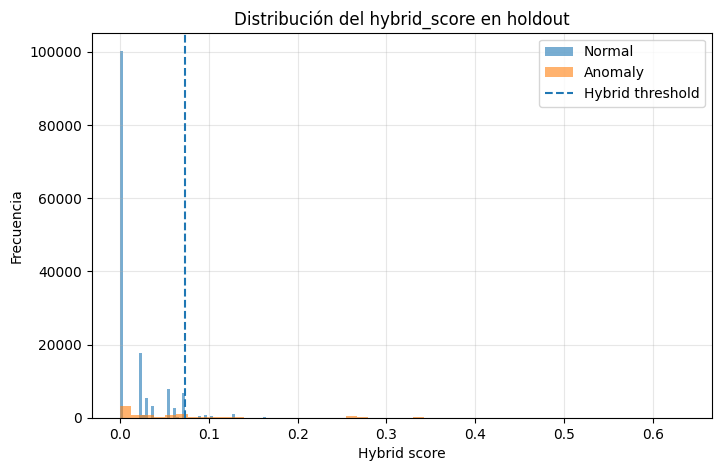

In [40]:
plt.figure(figsize=(8, 5))
plt.hist(
    holdout_df.loc[holdout_df["is_synthetic"] == 0, "hybrid_score"],
    bins=50,
    alpha=0.6,
    label="Normal"
)
plt.hist(
    holdout_df.loc[holdout_df["is_synthetic"] == 1, "hybrid_score"],
    bins=50,
    alpha=0.6,
    label="Anomaly"
)
plt.axvline(selected_threshold, linestyle="--", label="Hybrid threshold")
plt.title("Distribución del hybrid_score en holdout")
plt.xlabel("Hybrid score")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Mejora del híbrido: enfoque contextual por tipo de barco



En esta sección se explora una mejora del sistema híbrido basada en contexto.

En lugar de utilizar un único threshold global para todos los segmentos, se calcula un threshold específico por `ship_type`, con el objetivo de adaptarse a la variabilidad del comportamiento entre distintos tipos de buques.

In [42]:
y_val = validation_df["is_synthetic"].values

# nos quedamos con lo necesario
val_context = validation_df.copy()

Calcular threshold por tipo de barco

In [43]:
context_thresholds = {}

for ship in val_context["ship_type"].unique():

    subset = val_context[val_context["ship_type"] == ship]

    if len(subset) < 50:
        continue  # evitar tipos con muy pocos datos

    y_sub = subset["is_synthetic"].values
    scores = subset["hybrid_score"].values

    best_row = None
    results = []

    for p in range(80, 100):
        thr = np.percentile(scores, p)
        pred = (scores > thr).astype(int)

        prec = precision_score(y_sub, pred, zero_division=0)
        rec = recall_score(y_sub, pred, zero_division=0)
        f1 = f1_score(y_sub, pred, zero_division=0)

        results.append((p, thr, prec, rec, f1))

    df_tmp = pd.DataFrame(results, columns=["p", "thr", "precision", "recall", "f1"])

    # mismo criterio que antes
    valid = df_tmp[df_tmp["precision"] >= 0.30]

    if len(valid) > 0:
        best = valid.sort_values(["recall", "f1"], ascending=False).iloc[0]
    else:
        best = df_tmp.sort_values(["recall", "f1"], ascending=False).iloc[0]

    context_thresholds[ship] = best["thr"]

context_thresholds

{'Tanker': np.float64(0.05370111171922722),
 'Service': np.float64(0.07318807993732854),
 'Cargo': np.float64(0.06099649172833075),
 'Other': np.float64(0.07366652113098805),
 'Special_Craft': np.float64(0.07320766823118109),
 'Passenger': np.float64(0.07318932304900046),
 'Undefined': np.float64(0.07318200959212393),
 'High_Speed': np.float64(0.0536740477572261),
 'WIG': np.float64(0.07322785645107911)}

In [44]:
def contextual_prediction(row, thresholds, default_thr):
    ship = row["ship_type"]

    if ship in thresholds:
        thr = thresholds[ship]
    else:
        thr = default_thr

    return int(row["hybrid_score"] > thr)


# usamos el threshold global como fallback
default_thr = selected_threshold

holdout_df["hybrid_context_pred"] = holdout_df.apply(
    lambda row: contextual_prediction(row, context_thresholds, default_thr),
    axis=1
)

In [45]:
context_metrics = get_metrics(
    y_holdout,
    holdout_df["hybrid_context_pred"]
)

print("Hybrid contextual metrics:", context_metrics)

Hybrid contextual metrics: {'precision': 0.3314471636723723, 'recall': 0.2647457627118644, 'f1': 0.29436522394622777}


In [46]:
comparison_df_context = pd.DataFrame([
    {"model": "AE_tuned", **ae_metrics},
    {"model": "LOF", **lof_metrics},
    {"model": "Hybrid_global", **hybrid_metrics},
    {"model": "Hybrid_contextual", **context_metrics}
]).sort_values(["recall", "f1"], ascending=False)

comparison_df_context

,model,precision,recall,f1
1,LOF,0.369945,0.586102,0.453588
0,AE_tuned,0.580616,0.442712,0.502372
2,Hybrid_global,0.311091,0.271299,0.289836
3,Hybrid_contextual,0.331447,0.264746,0.294365


En conjunto, los experimentos realizados muestran que una combinación lineal entre el score del modelo y reglas expertas, incluso adaptada por contexto, no logra mejorar el rendimiento del sistema. Esto sugiere que la integración de conocimiento experto requiere enfoques más sofisticados, posiblemente basados en estructura de datos o agrupamiento previo.

## Guardado

In [47]:

# GUARDAR RESULTADOS COMPLETOS

# Guardar dataset final con todos los scores y predicciones
holdout_df.to_csv(
    hybrid_path + "holdout_with_all_scores.csv",
    index=False
)

# Guardar comparativa final (incluyendo contextual)
comparison_df_context.to_csv(
    hybrid_path + "hybrid_model_comparison_full.csv",
    index=False
)

# Guardar resumen de activación de reglas
rule_activation_summary.to_csv(
    hybrid_path + "rule_activation_summary.csv"
)

# Guardar diferencias normal vs anomalía
rule_by_class.to_csv(
    hybrid_path + "rule_difference_by_class.csv"
)


# METADATA COMPLETA DEL HÍBRIDO
hybrid_metadata = {
    "base_models": {
        "AE_tuned": ae_metrics,
        "LOF": lof_metrics
    },

    "hybrid_global": {
        "alpha": selected_alpha,
        "beta": selected_beta,
        "threshold": selected_threshold,
        "threshold_percentile": selected_percentile,
        "metrics_holdout": hybrid_metrics
    },

    "hybrid_contextual": {
        "thresholds_by_ship_type": context_thresholds,
        "default_threshold": selected_threshold,
        "metrics_holdout": context_metrics
    },

    "rule_system": {
        "rule_weights": rule_weights,
        "rule_columns": rule_cols
    },

    "features_used": {
        "ae_features": ae_features,
        "lof_features": lof_features
    },

    "conclusion": {
        "best_model": "AE_tuned",
        "insight": "Hybrid approaches (global and contextual) did not outperform AE_tuned or LOF. Rules provide interpretability but not predictive gain."
    }
}

# Guardar metadata
with open(hybrid_path + "hybrid_metadata_full.json", "w") as f:
    json.dump(hybrid_metadata, f, indent=4)


print("Guardado correctamente en:", hybrid_path)

✅ Todo guardado correctamente en: /content/drive/MyDrive/TFG/results/hybrid_scoring/


Aunque la integración lineal de reglas expertas no mejoró el rendimiento del detector final, sí permitió identificar señales interpretables asociadas a diferentes comportamientos anómalos. Por ello, en la siguiente fase se analiza la estructura interna de las anomalías mediante técnicas de clustering, con el fin de estudiar si existen grupos diferenciados y cómo se relacionan con las anomalías sintéticas, las predicciones del autoencoder y las reglas expertas activadas.